## Visualize results

In [1]:
import Pkg
Pkg.activate("..")
Pkg.instantiate()

  Activating project at `/home/synd/Wouter/Onderzoek/Projecten/tue/tgp-hopt-ar/hopt-bar`
Precompiling project...
   1556.2 ms  ? DomainSets
   2324.7 ms  ? DomainIntegrals
   3903.3 ms  ? BayesBase
   2765.3 ms  ? BayesBase → FastCholeskyExt
   2644.4 ms  ? ExponentialFamily
   3214.4 ms  ? ReactiveMP
   2966.7 ms  ? RxInfer


In [4]:
using Revise
using Distributions
using LinearAlgebra
using JLD2
using Plots; 
default(label="", linewidth=3, margin=15Plots.pt);


In [42]:
experiment_ids = 1:34

# Time parameters
Δt = 0.1
len_time = 100
tspan = (0.0, Δt*(len_time-1))
tsteps = range(0, step=Δt, length=len_time)
len_horizon = 3

# Preallocate result arrays
times_GP = zeros(length(experiment_ids))
times_AR = zeros(length(experiment_ids))
RMS_GP   = zeros(length(experiment_ids))
RMS_AR   = zeros(length(experiment_ids))
MML_GP   = zeros(length(experiment_ids))
MML_AR   = zeros(length(experiment_ids))

# Collect results
for (nn,id) in enumerate(experiment_ids)
    trialnum = lpad(id, 3, '0')

    res = load("results/experiment-AR1-trialnum$trialnum.jld2")
    times_GP[nn] = res["time_GP"]
    times_AR[nn] = res["time_AR"]
    RMS_GP[nn]   = res["RMS_GP"]
    RMS_AR[nn]   = res["RMS_AR"]
    MML_GP[nn]   = exp.(-res["NLE_GP"])
    MML_AR[nn]   = exp.(-res["NLE_AR"])

end

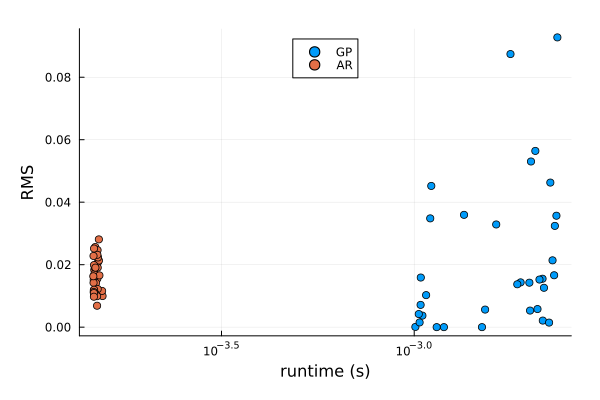

In [43]:
plot(xlabel="runtime (s)", ylabel="RMS", xscale=:log10, legend=:top)
scatter!(times_GP, RMS_GP, label="GP")
scatter!(times_AR, RMS_AR, label="AR")

In [46]:
MML_GP

34-element Vector{Float64}:
 3.75045001650192e35
 5.1339889607481724e103
 7.558284704564217e103
 2.3604004832839495e101
 1.1361316083578916e101
 3.5053508635323166e82
 4.442585544394853e101
 5.079640547461542e103
 3.25949158986614e102
 3.3462145758764766e103
 ⋮
 6.868960071900259e103
 9.58113540210449e100
 5.413404613442552e86
 1.7101004982493182e102
 9.044610273383096e103
 6.426112994692533e103
 1.0716067590732325e56
 2.144444641239571e103
 5.840990069186011e103

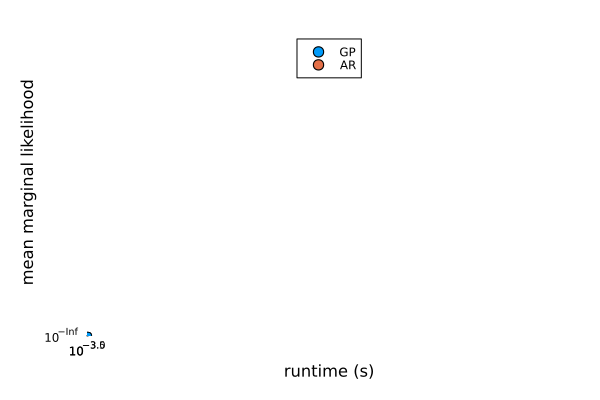

┌ Warning: No strict ticks found
└ @ PlotUtils /home/wmkouw/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /home/wmkouw/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /home/wmkouw/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /home/wmkouw/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /home/wmkouw/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /home/wmkouw/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /home/wmkouw/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194


In [45]:
plot(xlabel="runtime (s)", ylabel="mean marginal likelihood", xscale=:log10, yscale=:log10, legend=:top)
scatter!(times_GP, MML_GP, label="GP")
scatter!(times_AR, MML_AR, label="AR")